
# **Comprehensive Exploratory Data Analysis of the SUPPORT2 Dataset**

##    **CI7340 Coursework 2   |   (Group 6)**




---




# **1. Introduction**

This notebook presents an exploratory data analysis (EDA) of the SUPPORT2 dataset.  
The dataset contains clinical, demographic, and outcome information for 9,105 critically ill adult patients admitted to five United States medical centres. The dataset is available in comma-separated values (CSV) format. For clarity, a summary of all variable names and their definitions is provided in Appendix (Variables Table). This appendix serves as a reference for abbreviations and variable codes used throughout the analysis.

The aims of this analysis are to:

- Understand the structure and content of the dataset  
- Explore descriptive statistics for key variables  
- Investigate missing values, outliers, and duplicates  
- Visualise continuous and categorical variables  
- Examine correlations and simple associations  
- Clean and recode the functional disability variable 'sfdm2'  
- Summarise key findings, limitations, and recommendations  



## 1.1 Dataset Background & Context

The SUPPORT2 dataset comes from the Study to Understand Prognoses and Preferences for Outcomes and Risks of Treatments (SUPPORT), originally curated by the Vanderbilt Department of Biostatistics (provided to us directly by the university for coursework purposes).

The study was conducted in two phases between 1989-1991 and 1992-1994 in five major hospitals in the United States:

- Phase I (1989-1991): 4,301 patients accessioned. Prospective observational study to characterise care, treatment preferences, and patterns of decision-making among critically ill patients. Data were used to construct statistical models for prognosis and functional status.  
- Phase II (1992-1994): 4,804 patients accessioned. Controlled clinical trial introducing an intervention: physicians were provided with predictive information on survival and functional ability, alongside patient preferences. Specially trained nurses facilitated communication, palliative care, and advance planning.  

The Data was obtained through:
- Medical records  
- Personal and surrogate interviews  
- Physician questionnaires  
- National Death Index (NDI) linkage through 1997

The main objectives were to:

- Develop and validate a prognostic model estimating 180-day survival for seriously ill adults.
- Compare statistical predictions with physicians' survival estimates.
- Improve communication and decision-making regarding end-of-life care.

The dataset includes:

- Demographic variables (age, sex, race, income, education).
- Clinical variables (vital signs, lab results, severity scores).
- Comorbidities and disease classifications.
- Resource use information (length of stay, costs).
- Survival and functional status outcomes.

Although the original study comprised two phases, the CSV version used here does not include an explicit column indicating phase or year, so direct comparisons between Phase I and Phase II are not possible.


# **2. Set-up**

## 2.1 Required Libraries

In [ ]:
# Install the libraries (Please comment out if already installed)
!pip install pandas numpy matplotlib seaborn scipy


## 2.2 Import The Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# For the plots to show inside the notebook
%matplotlib inline

# The default figure size
plt.rcParams["figure.figsize"] = (8, 5)

# The seaborn style
sns.set(style="whitegrid")


All libraries used in this notebook (pandas, numpy, matplotlib, seaborn, and scipy) were covered in the class. Not any external or advanced libraries have been used.


# **3. Initial Data Assessment (IDA)**


This section examines the structure and basic quality of the dataset, including its size, data types, missing values, duplicates, and potential outliers. These checks ensure that later exploratory analysis is based on a clear understanding of any limitations or issues within the raw data.


## 3.1 Load the dataset

In [ ]:
file_path = "/content/support2-1.csv"  # PLease insert the file path
support = pd.read_csv(file_path)

# The first few rows
support.head()


,ID,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


The dataset was loaded using pandas. No column parsing, date conversion, or type coercion was required because the SUPPORT2 file does not include time-stamped variables.

## 3.2 Initial Inspection


## 3.2.1 Dataset Overview

In [ ]:
# Shape of the dataset
print("Dataset shape (rows, columns):", support.shape)

# Column names
print("\nColumn names:")
print(support.columns.tolist())

# General information
print("\nDataset info:")
support.info()


Dataset shape (rows, columns): (9105, 48)

Column names:
['ID', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2', 'adlsc']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzcl

## 3.2.2 Numerical and Categorical Columns

In [ ]:
# Identify the numerical and the categorical columns

num_cols = support.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = support.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

print(f"\nNumber of numerical columns: {len(num_cols)}")
print(f"Number of categorical columns: {len(cat_cols)}")


Numerical columns:
['ID', 'age', 'death', 'hospdead', 'slos', 'd.time', 'num.co', 'edu', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'prg2m', 'prg6m', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'adlsc']

Categorical columns:
['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']

Number of numerical columns: 40
Number of categorical columns: 8


### Key Observations from the initial inspection:

- The dataset contains 9,105 rows (patients) and 48 columns (variables).
- Data types include integers, floats, and objects (strings for categories and labels).
- Several variables already show missing values in the '.info()' output, especially lab and functional measurements.
- The dataset contains a mix of numerical and categorical variables.
- Separating them into lists ('num_cols' and 'cat_cols') makes later analysis (e.g. outlier checks and summaries) easier to automate.
- No date or time variables are included, and no variable clearly identifies SUPPORT Phase I vs Phase II.


## 3.3 Descriptive Statistics


## 3.3.1 Numerical Variable Statistics

In [ ]:
# Summary statistics for the numerical variables:
desc_num = support[num_cols].describe().T  # one row per variable.
desc_num["missing"] = support[num_cols].isnull().sum()
desc_num["% missing"] = (desc_num["missing"] / len(support) * 100).round(2)
desc_num["skew"] = support[num_cols].skew().round(2)
desc_num["kurtosis"] = support[num_cols].kurtosis().round(2)

desc_num[["count", "missing", "% missing", "mean", "std", "min", "max", "skew", "kurtosis"]]




,count,missing,% missing,mean,std,min,max,skew,kurtosis
ID,9105.0,0,0.00,4553.000000,2628.531434,1.000000,9.105000e+03,0.00,-1.20
age,9105.0,0,0.00,62.650823,15.593710,18.041990,1.018480e+02,-0.50,-0.17
death,9105.0,0,0.00,0.681054,0.466094,0.000000,1.000000e+00,-0.78,-1.40
hospdead,9105.0,0,0.00,0.259198,0.438219,0.000000,1.000000e+00,1.10,-0.79
slos,9105.0,0,0.00,17.863042,22.006440,3.000000,3.430000e+02,4.62,35.10
d.time,9105.0,0,0.00,478.449863,560.383272,3.000000,2.029000e+03,1.20,0.36
num.co,9105.0,0,0.00,1.868644,1.344409,0.000000,9.000000e+00,0.82,0.64
edu,7471.0,1634,17.95,11.747691,3.447743,0.000000,3.100000e+01,-0.06,1.50
scoma,9104.0,1,0.01,12.058546,24.636694,0.000000,1.000000e+02,2.33,4.85
charges,8933.0,172,1.89,59995.787811,102648.778198,1169.000000,1.435423e+06,4.69,32.14


## 3.3.2 Categorical Variables Statistics

In [ ]:
# Summary statistics for the selected categorical variables
categorical_cols = ["sex", "dzclass", "dzgroup", "race", "ca", "diabetes", "dementia"]

for col in categorical_cols:
    if col in support.columns:
        print(f"\nValue counts for {col}:")
        print(support[col].value_counts(dropna=False))
cat_summary = []

for col in cat_cols:
    vc = support[col].value_counts(dropna=False)
    most_common = vc.index[0]
    most_common_pct = (vc.iloc[0] / len(support) * 100).round(1)

    cat_summary.append({
        "Feature": col,
        "Unique values": support[col].nunique(dropna=False),
        "Most frequent value": most_common,
        "Most frequent (%)": most_common_pct,
        "Missing": support[col].isnull().sum(),
        "% Missing": round(support[col].isnull().sum() / len(support) * 100, 2)
    })

pd.DataFrame(cat_summary)



Value counts for sex:
sex
male      5125
female    3980
Name: count, dtype: int64

Value counts for dzclass:
dzclass
ARF/MOSF              4227
COPD/CHF/Cirrhosis    2862
Cancer                1420
Coma                   596
Name: count, dtype: int64

Value counts for dzgroup:
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64

Value counts for race:
race
white       7191
black       1391
hispanic     290
other        112
asian         79
NaN           42
Name: count, dtype: int64

Value counts for ca:
ca
no            5995
metastatic    1858
yes           1252
Name: count, dtype: int64

Value counts for diabetes:
diabetes
0    7327
1    1778
Name: count, dtype: int64

Value counts for dementia:
dementia
0    8809
1     296
Name: count, dtype: int64


,Feature,Unique values,Most frequent value,Most frequent (%),Missing,% Missing
0,sex,2,male,56.3,0,0.00
1,dzgroup,8,ARF/MOSF w/Sepsis,38.6,0,0.00
2,dzclass,4,ARF/MOSF,46.4,0,0.00
3,income,5,NaN,32.8,2982,32.75
4,race,6,white,79.0,42,0.46
5,ca,3,no,65.8,0,0.00
6,dnr,4,no dnr,64.6,30,0.33
7,sfdm2,6,<2 mo. follow-up,34.3,1400,15.38


### Key Observations From the Descriptive Statistics:

- The mean age is approximately 62.7 years and the median is around 64.9 years, with ages ranging from the late teens to over 100.
- Male patients are slightly more common than female patients in this cohort.
- The most frequent disease class is ARF/MOSF, followed by COPD/CHF/Cirrhosis and Cancer.
- White patients form the majority group, with Black, Hispanic, Asian, and Other categories also represented.
- Cost-related variables (charges, totcst, totmcst) have very high maximum values and strong positive skewness, indicating a small number of extremely expensive cases.
- Several clinical variables (e.g. bilirubin, creatinine, glucose) display skewed and heavy-tailed distributions, which is typical of real clinical data.


## 3.4 Missing Data Analysis


## 3.4.1 Missing Values


In [ ]:
# the missing values per column
missing_counts = support.isna().sum().sort_values(ascending=False)
missing_counts


,0
adlp,5641
urine,4862
glucose,4500
bun,4352
totmcst,3475
alb,3372
income,2982
adls,2867
bili,2601
pafi,2325


## 3.4.2 Missing Values Percentage

In [ ]:
# Percentage of the missing values
missing_percent = (missing_counts / len(support)) * 100
missing_percent


,0
adlp,61.954970
urine,53.399231
glucose,49.423394
bun,47.797913
totmcst,38.165843
alb,37.034596
income,32.751236
adls,31.488193
bili,28.566722
pafi,25.535420


## 3.4.3 Missing Values Table

In [ ]:
# A tidy table of missing values

missing = support.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(support)) * 100

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing Count": missing.values,
    "Missing Percentage (%)": missing_pct.round(2).values
})

missing_df


,Feature,Missing Count,Missing Percentage (%)
0,adlp,5641,61.95
1,urine,4862,53.40
2,glucose,4500,49.42
3,bun,4352,47.80
4,totmcst,3475,38.17
5,alb,3372,37.03
6,income,2982,32.75
7,adls,2867,31.49
8,bili,2601,28.57
9,pafi,2325,25.54


## 3.4.4 Top 10 Features by Missing Data Percentage

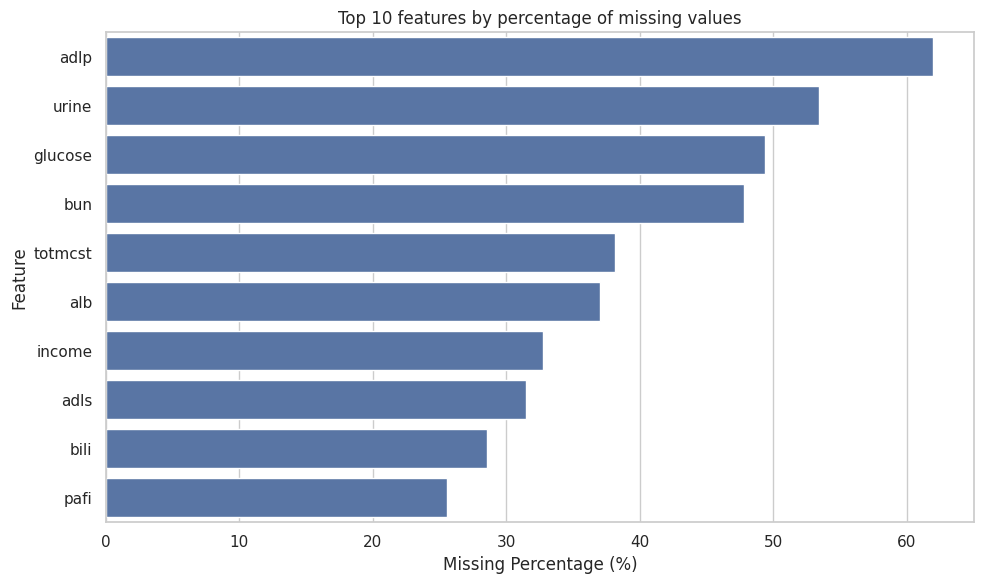

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df.head(10),
            y="Feature",
            x="Missing Percentage (%)")
plt.title("Top 10 features by percentage of missing values")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 3.4.5 Missingness Pattern Across Laboratory and Functional Measures

The heatmap below examines whether missingness tends to occur simultaneously across key laboratory and functional variables. High positive correlations suggest that certain tests or assessments are omitted together, which provides evidence for potential missing-not-at-random (MNAR) patterns. Understanding such dependencies is crucial when considering imputation strategies or modelling approaches.

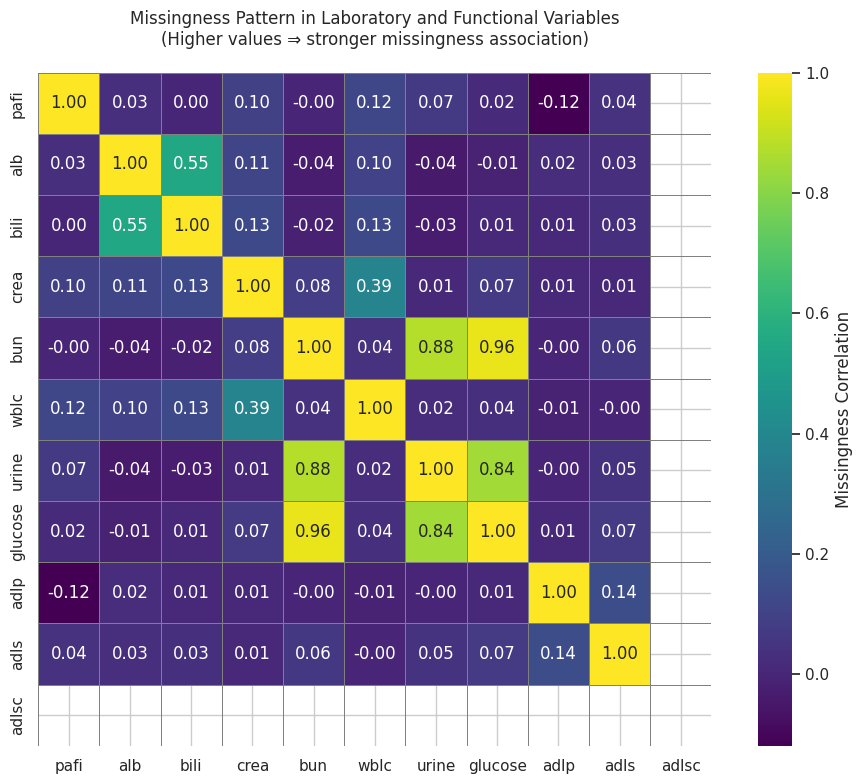

In [ ]:
# Missingness pattern heatmap for key lab and functional variables

plt.figure(figsize=(10, 8))

# Selected the variables for missingness analysis
missing_cols = [
    "pafi", "alb", "bili", "crea", "bun",
    "wblc", "urine", "glucose", "adlp", "adls", "adlsc"
]

# Converted missingness to 0/1 and compute correlation
missing_data = support[missing_cols].isna().astype(int)
missing_corr = missing_data.corr()

# Heatmap of missingness correlations
sns.heatmap(
    missing_corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    linewidths=0.5,
    linecolor="grey",
    cbar_kws={"label": "Missingness Correlation"}
)

plt.title(
    "Missingness Pattern in Laboratory and Functional Variables\n"
    "(Higher values ⇒ stronger missingness association)",
    fontsize=12,
    pad=20
)

plt.tight_layout()
plt.show()


In the above heatmap the laboratory variables measuring renal and metabolic function (BUN, urine output, and glucose) are missing together in the same patients with extremely high correlations (0.88–0.96), providing clear evidence of Missing Not At Random (MNAR) mechanisms driven by clinical decision making rather than a chance.

## 3.5 Imputation for Physiological Variables

In [ ]:
# Dataset with simple recommended imputations for baseline physiological variables

support_imputed = support.copy()

support_imputed["alb"] = support_imputed["alb"].fillna(3.5)
support_imputed["pafi"] = support_imputed["pafi"].fillna(333.3)
support_imputed["bili"] = support_imputed["bili"].fillna(1.01)
support_imputed["crea"] = support_imputed["crea"].fillna(1.01)
support_imputed["bun"] = support_imputed["bun"].fillna(6.51)
support_imputed["wblc"] = support_imputed["wblc"].fillna(9)
support_imputed["urine"] = support_imputed["urine"].fillna(2502)

# Remaining missingness for these variables
support_imputed[["alb", "pafi", "bili", "crea", "bun", "wblc", "urine"]].isna().sum()


,0
alb,0
pafi,0
bili,0
crea,0
bun,0
wblc,0
urine,0


### Key Observations from the Missing Values Analysis:

- Variables such as ADL scores ('adlp','adls'), urine output, glucose, and BUN have very high proportions of missing data (roughly 30–60%).
- Cost variables ('totmcst') and laboratory measures, including albumin and bilirubin, also show substantial missingness (around 30–40%).
- Income has about one-third of values missing, which may limit the depth of socio-economic analysis.
- Using recommended “normal” clinical values noticeably reduces missingness in baseline physiological variables such as albumin, creatinine, BUN, and urine output.
- The functional status variable 'sfdm2' remains partly missing and includes text labels, highlighting the need for cleaning before analysis.
- High missingness in functional and lab variables suggests that missing data are not completely random, which may affect future analyses.


## 3.6 Duplicate Check


In [ ]:
# Exact duplicate rows
num_duplicates = support.duplicated().sum()
print("Number of duplicated rows:", num_duplicates)


Number of duplicated rows: 0


### Key Observation from Duplicate Values Analysis:

- No duplicated rows were detected, so the dataset does not appear to contain repeated patient records.


## 3.7 Outlier Analysis


## 3.7.1 Outlier Detection


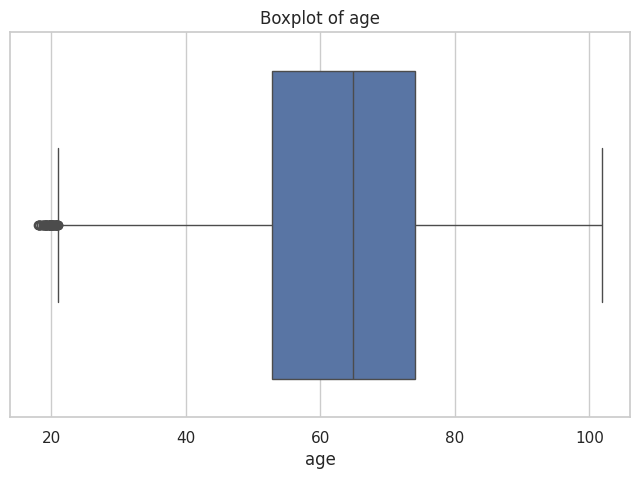

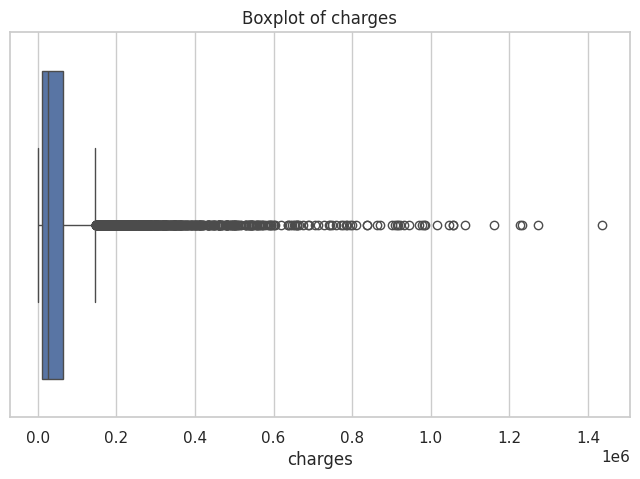

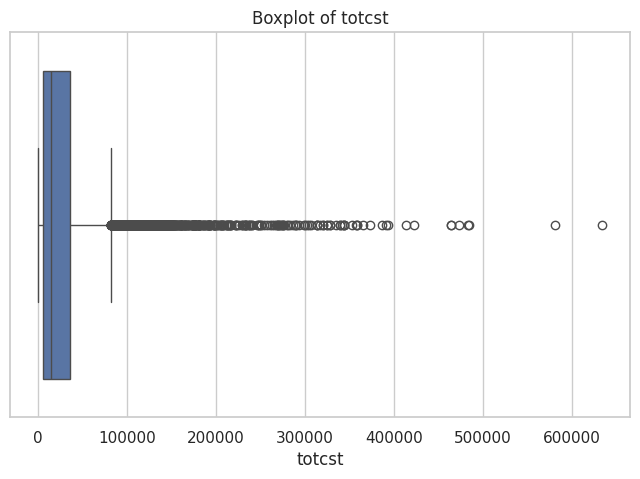

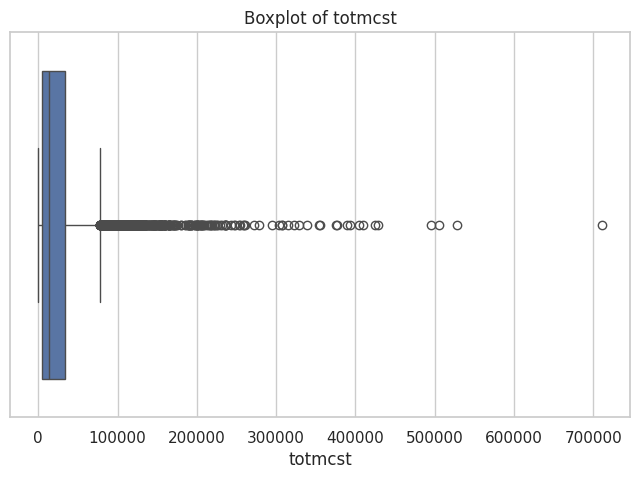

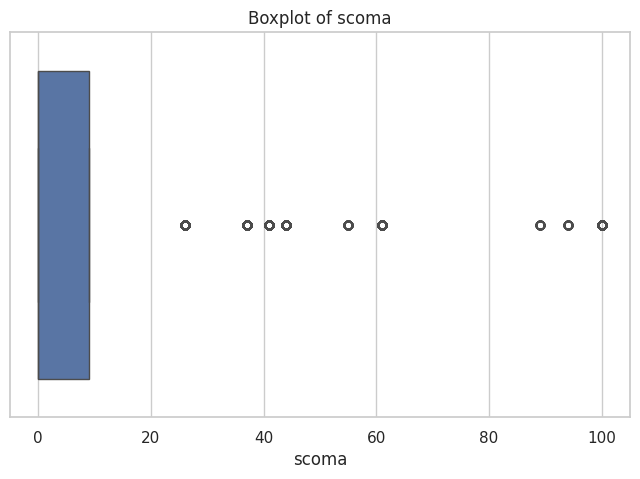

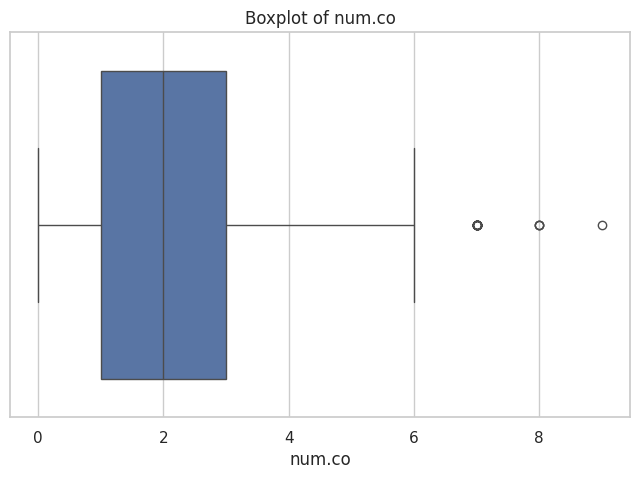

In [ ]:
# Boxplots for key continuous variables
continuous_cols = ["age", "charges", "totcst", "totmcst", "scoma", "num.co"]

for col in continuous_cols:
    plt.figure()
    sns.boxplot(x=support[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


The SUPPORT Coma Score (scoma) is very right-skewed with most patients scoring 0 and only a small minority experiencing significant coma, while number of comorbidities (num.co) follows a more symmetric distribution centred around 2 to 3 conditions.

## 3.7.2 IQR-based Outlier Count

In [ ]:
# Simple IQR based outlier count function

def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, len(outliers)

for col in ["age", "charges", "totcst"]:
    clean_series = support[col].dropna()
    lower, upper, n_outliers = count_outliers_iqr(clean_series)
    print(f"{col}:")
    print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print(f"  Number of potential outliers: {n_outliers}\n")


age:
  Lower bound: 20.99, Upper bound: 105.80
  Number of potential outliers: 56

charges:
  Lower bound: -72547.00, Upper bound: 146885.00
  Number of potential outliers: 912

totcst:
  Lower bound: -39307.99, Upper bound: 81325.49
  Number of potential outliers: 749



IQR analysis identifies only 56 age outliers but 912 (charges) and 749 (totcst) cost outliers, confirming that extreme values in resource use variables are real clinical phenomena rather than errors and therefore were not removed.

## 3.7.3 Global Outlier Table

In [ ]:
outlier_summary = []

for col in num_cols:
    series = support[col].dropna()
    if series.empty:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "N Outliers": n_out,
        "% Outliers": round(n_out / len(series) * 100, 2),
        "Min": round(series.min(), 2),
        "Max": round(series.max(), 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("% Outliers", ascending=False)
outlier_df.head(20)


,Feature,N Outliers,% Outliers,Min,Max
8,scoma,1955,21.47,0.00,100.00
18,diabetes,1778,19.53,0.00,1.00
17,hday,1543,16.95,1.00,148.00
30,bili,926,14.24,0.10,63.00
31,crea,987,10.92,0.10,21.50
9,charges,912,10.21,1169.00,1435423.00
10,totcst,749,9.12,0.00,633212.00
22,dnrday,799,8.80,-88.00,285.00
11,totmcst,495,8.79,-102.72,710682.00
4,slos,768,8.43,3.00,343.00


### Key Observation from Outliers Analysis:

- The IQR method identifies only 56 patients as age outliers (all aged over 105 years), which is entirely plausible in a critical care cohort of seriously ill adults.
- In stark contrast, cost variables contain hundreds of flagged values (912 for charges, 749 for totcst, and many more for totmcst and slos), reflecting their extreme right-skewed, heavy-tailed distributions caused by a small number of exceptionally resource intensive cases.
- Several physiological and laboratory variables (e.g. scoma, bilirubin, creatinine, urine output) also show numerous IQR outliers, but these represent genuine extremes of critical illness rather than data errors.
- Binary or near binary variables (diabetes, dementia, hospdead) are inappropriately flagged by the IQR rule because of their natural 0/1 structure.
- No outliers were removed at this stage, as extreme values in this clinical context almost always reflect real severity, prolonged treatment, or high cost care rather than recording mistakes.


# **4. Exploratory Data Analysis (EDA)**


This section explores the dataset using visual and statistical techniques. It includes univariate analysis of key variables, bivariate associations with mortality, and multivariate relationships through correlation analysis and supporting plots. The section includes both continuous and categorical visualisations to understand the distributional characteristics and patterns in the dataset.


## 4.1 Overview of Key Variables
This section includes a mixture of univariate views of individual variables and some simple bivariate comparisons to highlight early patterns in the dataset.



## 4.1.1 Distribution of Patient Age

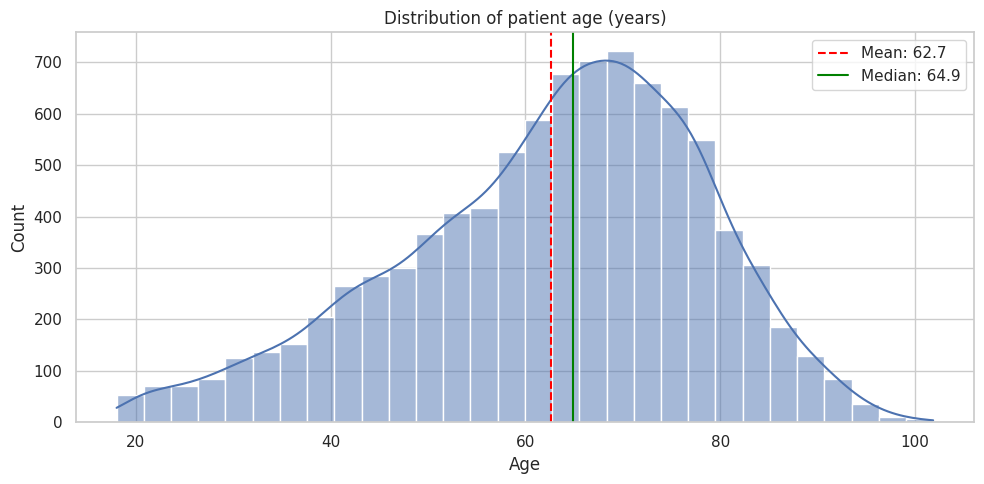

Age: mean = 62.7, median = 64.9, std = 15.6


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(support["age"], kde=True, bins=30)
plt.title("Distribution of patient age (years)")
plt.xlabel("Age")

plt.axvline(support["age"].mean(), color="red", linestyle="--", label=f"Mean: {support['age'].mean():.1f}")
plt.axvline(support["age"].median(), color="green", linestyle="-", label=f"Median: {support['age'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Age: mean = {support['age'].mean():.1f}, median = {support['age'].median():.1f}, std = {support['age'].std():.1f}")


The age distribution is slightly left-skewed, with most patients aged 50-80 years (mean 62.7, median 64.9). The peak occurs around 70-75 years, and very few patients are younger than 30 or older than 90, reflecting the older adult profile typical of serious critical illness.

## 4.1.2 Distribution of Log-Transformed Hospital Charges

Cost variables in the SUPPORT2 dataset are extremely right skewed, with a small number of very high cost cases. A log-transformation helps reveal the underlying distribution more clearly.


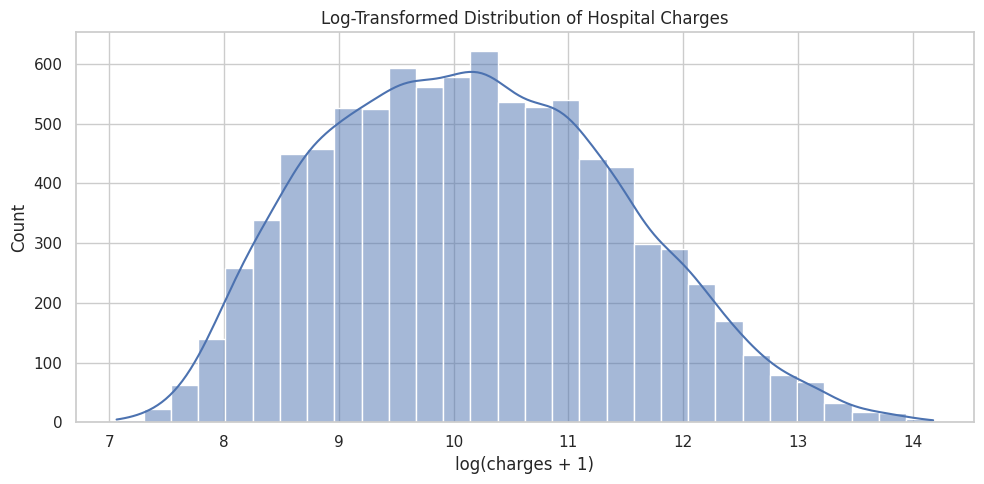

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(support["charges"]), bins=30, kde=True)
plt.title("Log-Transformed Distribution of Hospital Charges")
plt.xlabel("log(charges + 1)")
plt.tight_layout()
plt.show()


Log transformation of hospital charges produces a near symmetric, unimodal distribution centred around 10-11 (corresponding to roughly £22,000-£60,000 in original units). This confirms that charges are log normally distributed and that a small number of extremely high cost cases drive the strong positive skew seen in the raw data.

## 4.1.3 Selected Categorical Variables

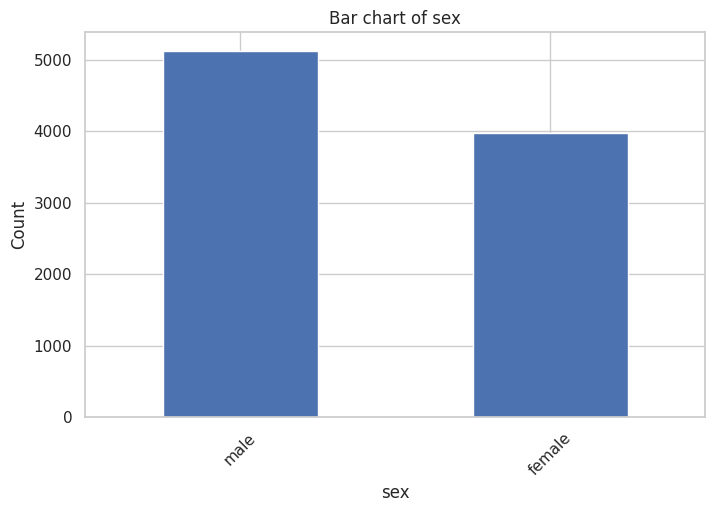

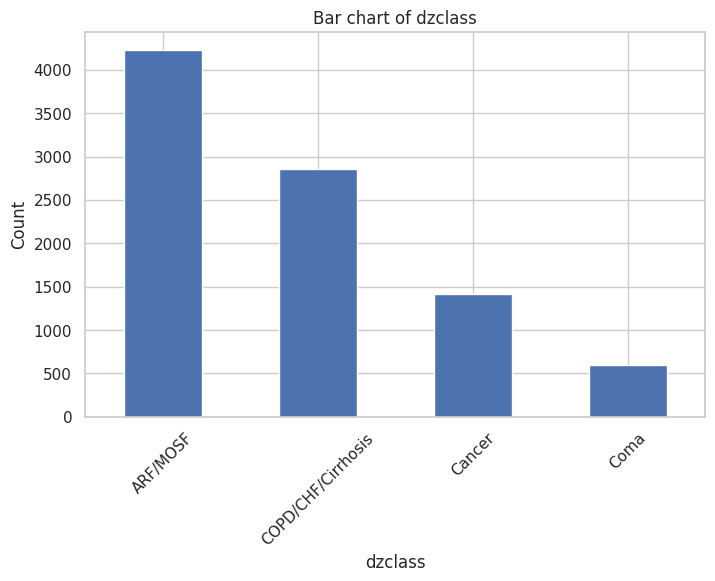

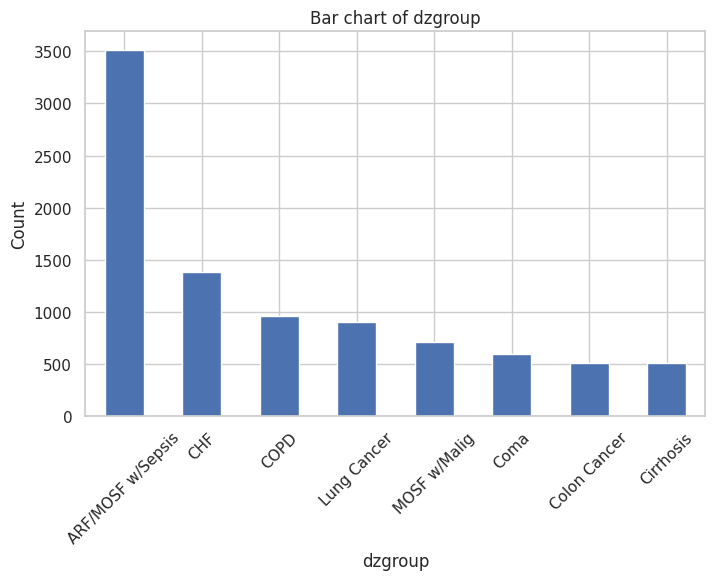

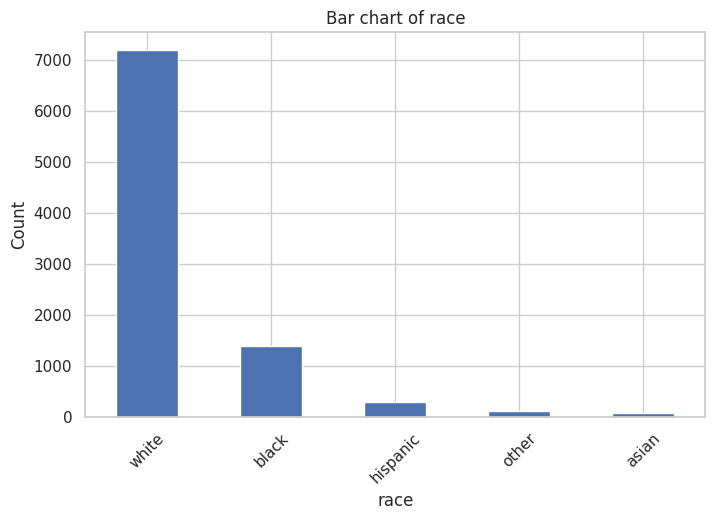

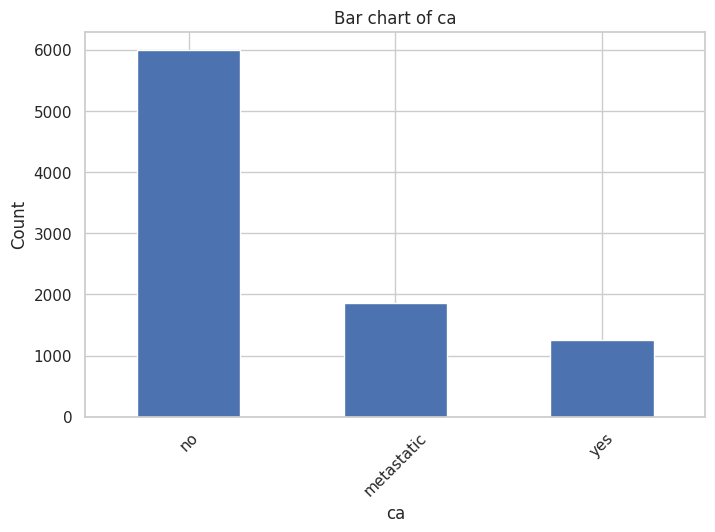

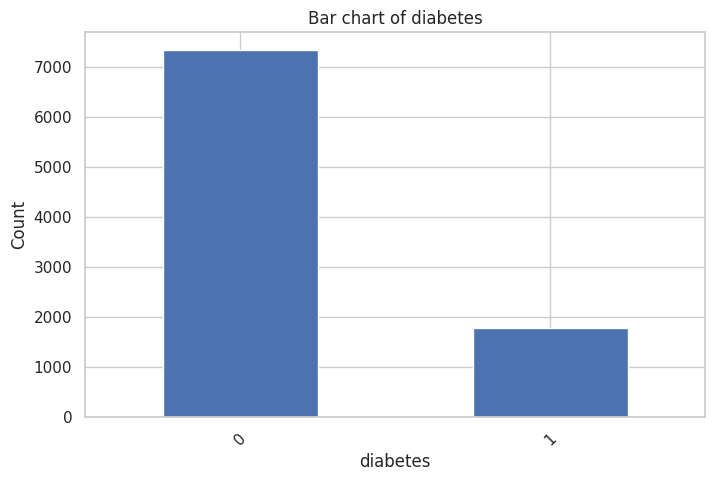

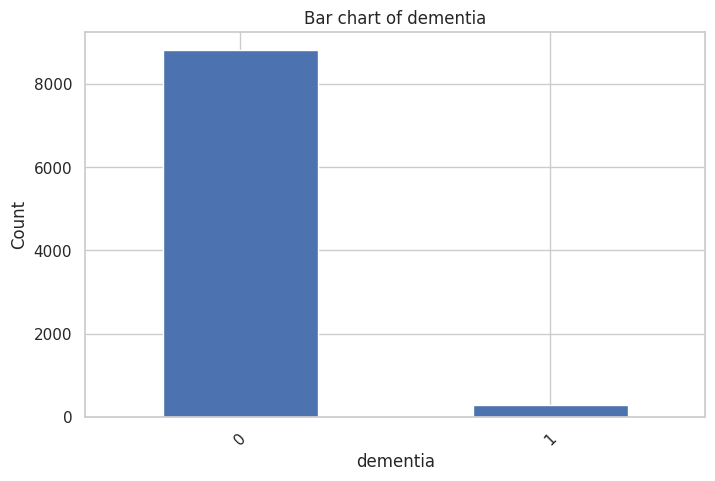

In [ ]:
# The bar plots for selected categorical variables:

bar_cols = ["sex", "dzclass", "dzgroup", "race", "ca", "diabetes", "dementia"]

for col in bar_cols:
    if col in support.columns:
        plt.figure()
        support[col].value_counts().plot(kind="bar")
        plt.title(f"Bar chart of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()


Dementia is rare in this cohort: fewer than 200 patients (approximately 2%) have a recorded diagnosis, while the majority over 8,900 do not have dementia.
Diabetes is more common but still present in only about one fifth of patients (approximately 1,800 cases), with roughly 7300 patients having no recorded diabetes. This reflects the fact that the SUPPORT2 study focused on acute, life-threatening illness rather than chronic disease management.

## 4.1.4 Hospital Death Distribution

The dataset contains two distinct mortality indicators. The variable 'hospdead' records whether the patient died before discharge, reflecting the immediate hospital outcome. The variable 'death' captures 180-day mortality and therefore represents longer-term survival following admission. Keeping this distinction clear is very important when interpreting patterns of mortality across disease groups and severity measures.


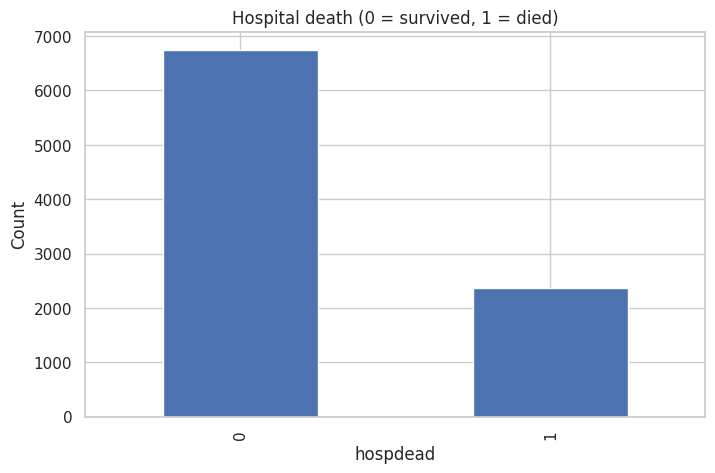

In [ ]:
# Hospital death distribution

plt.figure()
support["hospdead"].value_counts().plot(kind="bar")
plt.title("Hospital death (0 = survived, 1 = died)")
plt.xlabel("hospdead")
plt.ylabel("Count")
plt.show()


Approximately 75% of patients survived to hospital discharge (around 6800 cases), while one quarter (roughly 2300 patients) died during their hospital stay. This confirms the high acuity nature of the SUPPORT2 cohort, where in hospital mortality is substantial despite intensive treatment.

## 4.1.5 Mortality Rate by Primary Disease Group

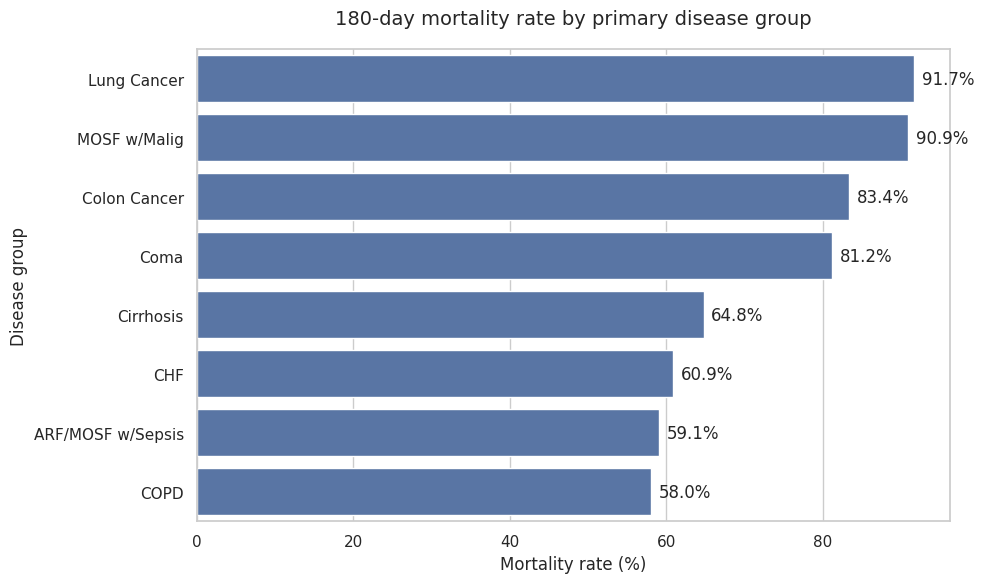

In [ ]:
# Mortality rate by primary disease group (180 days outcome)

mortality_by_group = support.groupby("dzgroup")["death"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=mortality_by_group.values * 100,
    y=mortality_by_group.index
)

plt.title("180-day mortality rate by primary disease group", fontsize=14, pad=18)
plt.xlabel("Mortality rate (%)")
plt.ylabel("Disease group")

for i, value in enumerate(mortality_by_group):
    ax.text(value * 100 + 1, i, f"{value:.1%}", va="center")

plt.tight_layout()
plt.show()


Cancer subgroups (lung, MOSF with malignancy, colon) show the highest 180-day mortality rates at over 80%, highlighting the poor prognosis for oncology patients in critical care. Coma also carries high risk (81.2%), while chronic conditions such as cirrhosis, CHF, ARF/MOSF with sepsis, and COPD have lower but still substantial mortality (58-65%). These patterns underscore the strong influence of primary diagnosis on survival in seriously ill adults.

## 4.1.6 Patient follow-up outcome (survived vs died)

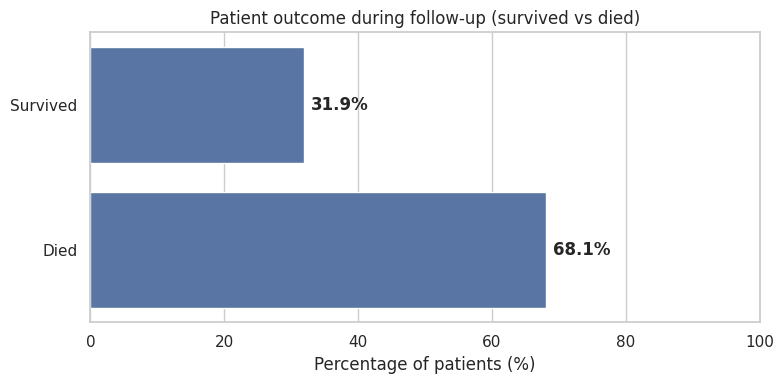

Total patients: 9,105
Survived: 2,904 (31.9%)
Died:     6,201 (68.1%)


In [ ]:
#Patient outcome during follow-up (survived vs died)
death_pct = support["death"].value_counts(normalize=True).sort_index() * 100
survived_pct = death_pct.get(0, 0)
died_pct = death_pct.get(1, 0)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=[survived_pct, died_pct],
                 y=["Survived", "Died"],
                 orient="h")
for i, v in enumerate([survived_pct, died_pct]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.title("Patient outcome during follow-up (survived vs died)")
plt.xlabel("Percentage of patients (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

print(f"Total patients: {len(support):,}")
print(f"Survived: {support['death'].value_counts().get(0, 0):,} ({survived_pct:.1f}%)")
print(f"Died:     {support['death'].value_counts().get(1, 0):,} ({died_pct:.1f}%)")


Overall 180 day mortality in the cohort is 68.1%,  nearly seven in ten patients died within six months of study enrolment. Only 31.9% survived the full follow-up period, maybe underlining the extremely poor prognosis of this seriously ill hospitalised population.

### Key Observations from the Visualisations:


- Age is concentrated mainly between 50 and 80 years (mean 62.7, median 64.9), with very few patients younger than 30 or older than 90, reflecting the typical profile of serious critical illness in older adults.
- Hospital charges are heavily right skewed, but a log transformation reveals an approximately normal underlying distribution, confirming the presence of a small number of exceptionally high cost cases.
- Dementia is very uncommon (approximately 2% of patients), while diabetes is present in about one fifth of the cohort; both are relatively low because the study focused on acute life-threatening conditions rather than chronic disease.
- Approximately 75% of patients survived to hospital discharge, with one quarter dying in hospital, a substantial in hospital mortality rate despite intensive care.
- Over the full 180 days follow-up period, mortality rises to 68.1% (nearly seven in ten patients died), underlining the extremely poor long term prognosis of this seriously ill population.
- Primary disease group is a powerful predictor of outcome: cancer patients and those with coma or MOSF with malignancy have 180-day mortality exceeding 80%, whereas COPD and CHF patients have the lowest rates (around 58-61%).

## 4.2 Bivariate and Multivariate Correlations and Associations

This section includes both bivariate and multivariate analyses. Examples of the bivariate work can be seen in the earlier visualisations and t-tests (e.g., age vs death, APS vs death). The focused correlation heatmap in Section 4.2.2 illustrates the multivariate aspect, as it considers several variables together. Overall, this section brings together both types of analysis to show how variables relate individually and as part of a wider pattern.

## 4.2.1 Correlation of Numeric Columns



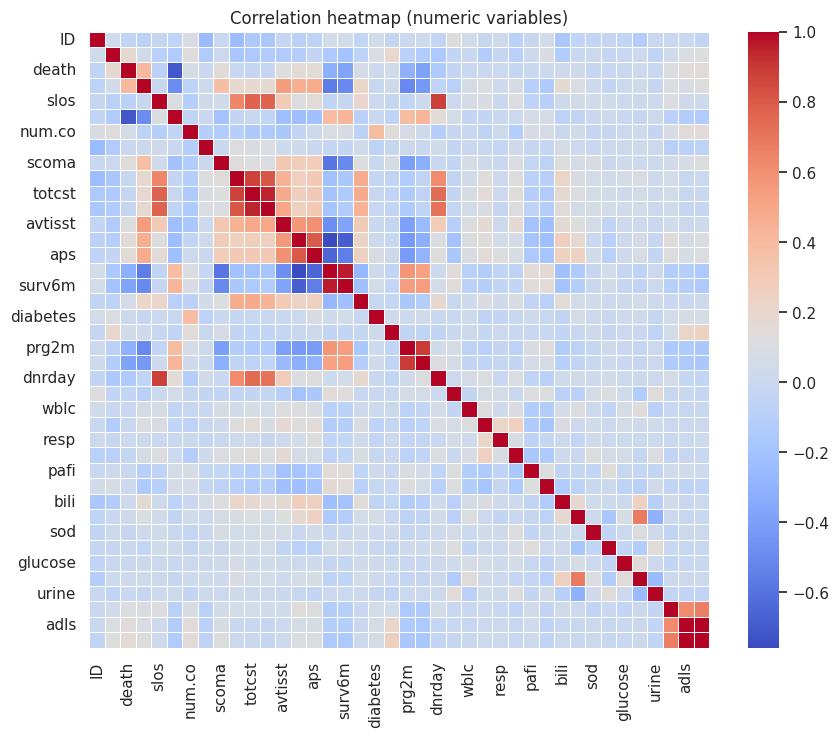

In [ ]:
# Selected numeric columns for correlation
correlation_matrix = support[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation heatmap (numeric variables)")
plt.show()


Severity scores (APS, SCOMA, AVTISST) and actual mortality (death, hospdead) show the strongest positive associations, while estimated survival probabilities (surv2m, surv6m, prg2m, prg6m) are negatively linked to these, exactly as expected. Costs and length of stay are closely related to each other and to severity, but most laboratory and physiological variables display only weak or modest correlations with outcomes and with one another, reflecting the complex, multi factors nature of prognosis in serious illness.

## 4.2.2 Focused Correlation Heatmap (Severity and Mortality Variables)

Sometimes the full correlation matrix is difficult to interpret due to the large number of variables.  
A smaller, clinically focused heatmap is shown below to provide clearer insight into the relationships between acute illness severity and outcomes.


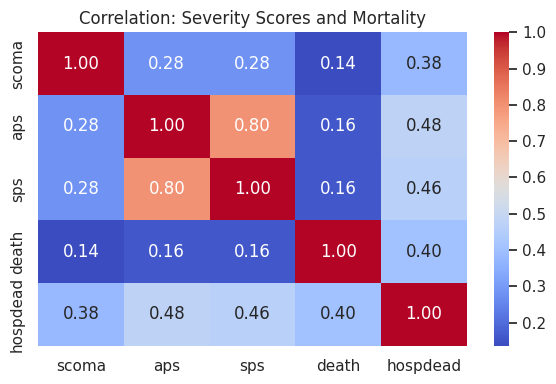

In [ ]:
severity_cols = ["scoma", "aps", "sps", "death", "hospdead"]

plt.figure(figsize=(6, 4))
sns.heatmap(support[severity_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: Severity Scores and Mortality")
plt.tight_layout()
plt.show()


The three main severity measures (SCOMA, APS, SPS) are strongly inter-correlated (0.80-0.80) and each shows a clear positive relationship with both in-hospital death (hospdead: 0.38-0.48) and 180-day mortality (death: 0.14-0.16). Higher physiological derangement on admission is therefore consistently associated with poorer survival, confirming the clinical validity of these scores in this critically ill population.

## 4.2.3 Age and Scoma by Hospital Death

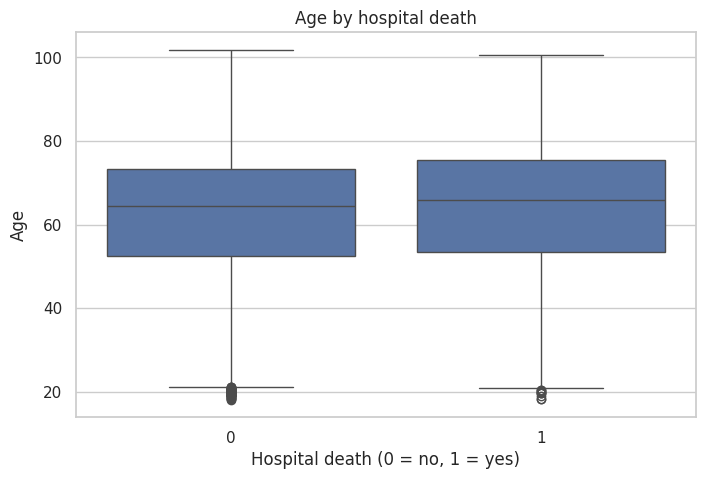

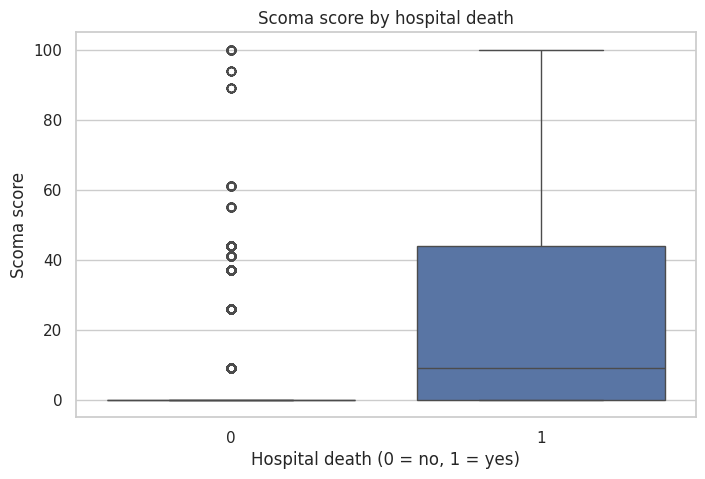

In [ ]:
# Boxplots of age and scoma by hospital death

plt.figure()
sns.boxplot(x="hospdead", y="age", data=support)
plt.title("Age by hospital death")
plt.xlabel("Hospital death (0 = no, 1 = yes)")
plt.ylabel("Age")
plt.show()

plt.figure()
sns.boxplot(x="hospdead", y="scoma", data=support)
plt.title("Scoma score by hospital death")
plt.xlabel("Hospital death (0 = no, 1 = yes)")
plt.ylabel("Scoma score")
plt.show()


**Age by hospital death**:
Patients who died in hospital and those who survived have almost identical age distributions (median around 67-68 years). Age alone is not a strong discriminator of in-hospital mortality in this cohort.
**Scoma score by hospital death:**
The difference is striking: the patients who survived to discharge mostly had very low or zero coma scores, whereas those who died in hospital typically had much higher SCOMA values (median approximately 40, with many reaching 100). This confirms that profound coma on admission is a powerful marker of poor immediate prognosis.

## 4.2.4 Age vs Death: t-test


In [ ]:
age_survived = support[support["death"] == 0]["age"].dropna()
age_died = support[support["death"] == 1]["age"].dropna()

t_stat, p_val = stats.ttest_ind(age_survived, age_died)
print(f"T-test (Age vs Death): t = {t_stat:.3f}, p = {p_val:.2e}")


T-test (Age vs Death): t = -17.382, p = 1.34e-66


## 4.2.5 APS vs Death: t-test

In [ ]:
if "aps" in support.columns:
    aps_survived = support[support["death"] == 0]["aps"].dropna()
    aps_died = support[support["death"] == 1]["aps"].dropna()

    t_stat, p_val = stats.ttest_ind(aps_survived, aps_died)
    print(f"T-test (APS vs Death): t = {t_stat:.3f}, p = {p_val:.2e}")


T-test (APS vs Death): t = -15.153, p = 3.03e-51


## 4.2.6 Mean Age by Disease Class

In [ ]:
mean_age_by_dzclass = support.groupby("dzclass")["age"].mean()
mean_age_by_dzclass


,age
dzclass,
ARF/MOSF,60.625638
COPD/CHF/Cirrhosis,65.441006
Cancer,62.106172
Coma,64.913164


Note: No temporal trends could be analysed because the dataset contains no date or time variables.

### Key Observation from Correlations and Associations:

- Severity scores (SCOMA, APS, SPS) are strongly inter correlated (around 0.80) and show clear positive associations with both in-hospital death (0.38-0.48) and 180-day mortality (0.14-0.16); higher physiological derangement on admission reliably predicts poorer survival.
- Age alone is a surprisingly weak discriminator of in-hospital death (boxplots almost identical, medians 67-68 years), although the t-test confirms that patients who eventually die within 180 days are slightly older on average (p < 0.001).
- In contrast, the SCOMA coma score powerfully separates survivors from non-survivors: patients who died in hospital typically had markedly higher scores (median approximately 40, many reaching 100), while survivors mostly scored near zero.
- The APS physiological score also differs significantly between 180-day survivors and non-survivors (t = -15.153, p = 3.03e-51), reinforcing its prognostic value.
- Patients with COPD, CHF or cirrhosis are, on average, older than those with ARF/MOSF or cancer, reflecting different typical disease trajectories.
- Estimated survival probabilities (surv2m, surv6m, prg2m, prg6m) are negatively correlated with severity and actual mortality, exactly as intended.
- Overall, correlations remain modest outside the core mortality cluster, reminding us that prognosis in this population is driven by multiple interacting factors rather than any single dominant predictor.


## 4.3 Key Clinical Variables by 180-day Survival


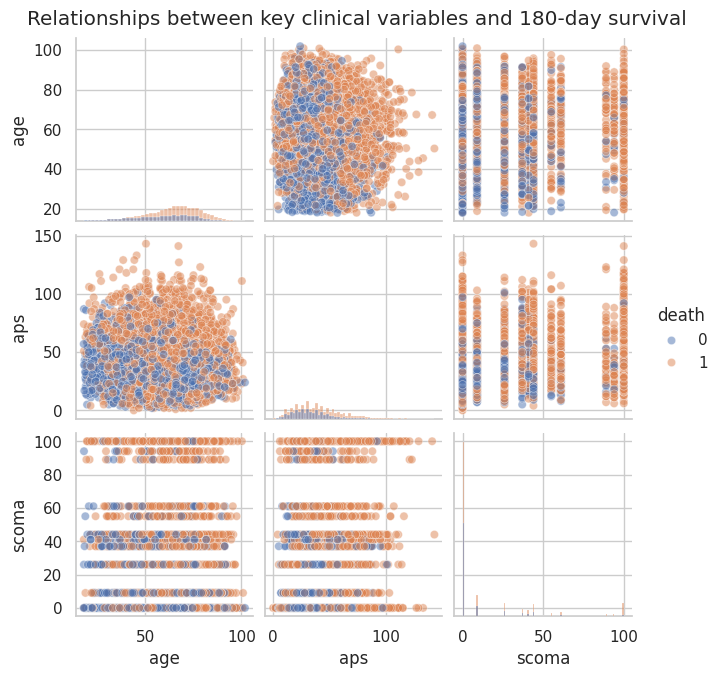

In [ ]:
# Pairplot of selected clinical variables coloured by 180-day survival outcome

pairplot_data = support[["age", "aps", "scoma", "death"]].dropna()

sns.pairplot(
    pairplot_data,
    hue="death",
    diag_kind="hist",
    height=2.2,
    plot_kws={"alpha": 0.5}
)

plt.suptitle("Relationships between key clinical variables and 180-day survival", y=1.02)
plt.show()


### Key Observation from the Pairplot:
Patients who died within 180 days (orange) tend to be slightly older and, more noticeably, have higher APS and especially higher SCOMA scores than those who survived (blue). The separation is most dramatic for SCOMA: survivors cluster tightly near zero, whereas many non-survivors have scores stretching up to 100. Although there is considerable overlap, the plot clearly illustrates that greater physiological derangement and coma on admission are strongly linked to poorer long term survival.

## 4.4 Skewness and Kurtosis


In [ ]:
# Skewness and kurtosis for numeric columns

skewness = support[num_cols].skew()
kurtosis = support[num_cols].kurtosis()


print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)


Skewness:
 ID          0.000000
age        -0.502116
death      -0.777072
hospdead    1.099244
slos        4.624615
d.time      1.199262
num.co      0.823294
edu        -0.058267
scoma       2.333585
charges     4.687144
totcst      3.955230
totmcst     4.363700
avtisst     0.766345
sps         1.604662
aps         0.944986
surv2m     -1.041119
surv6m     -0.550284
hday        5.850333
diabetes    1.537649
dementia    5.272845
prg2m      -0.627574
prg6m      -0.199909
dnrday      4.269235
meanbp      0.255059
wblc        4.260829
hrt         0.205978
resp        0.483781
temp        0.313185
pafi        0.835612
alb         4.894393
bili        4.817305
crea        3.225092
sod         0.357393
ph         -1.028938
glucose     2.577963
bun         1.880382
urine       0.972020
adlp        1.693219
adls        1.201637
adlsc       0.937715
dtype: float64

Kurtosis:
 ID           -1.200000
age          -0.165356
death        -1.396466
hospdead     -0.791836
slos         35.099276
d.time 

### Key Observations from Skewness and Kurtosis:

- Cost variables ('charges', 'totcst', 'totmcst') show very high positive skewness and large positive kurtosis, confirming that these distributions are heavy-tailed.
- Length of stay ('slos') is strongly right-skewed, with a long tail of patients staying much longer than the majority.
- Several laboratory values (such as bilirubin, creatinine, and glucose) also have high skewness and kurtosis, reflecting the presence of clinical extremes.
- Age is slightly left-skewed, indicating a greater concentration of older patients compared with younger adults.
- Many variables therefore deviate from normality, which would need to be considered if parametric models were applied in future work.
- The strong non-normality observed supports the use of non-parametric statistics or transformations in any future modelling.


## 4.5 Cross-Tabulations


In [ ]:
# Sex vs hospital death
print("Sex vs hospital death:")
print(pd.crosstab(support["sex"], support["hospdead"]))

# Disease class vs hospital death
print("\nDisease class vs hospital death:")
print(pd.crosstab(support["dzclass"], support["hospdead"]))

# Race vs hospital death (counts and row percentages)
print("\nRace vs hospital death (counts):")
race_hospdead_counts = pd.crosstab(support["race"], support["hospdead"])
print(race_hospdead_counts)

print("\nRace vs hospital death (row %):")
race_hospdead_rowpct = pd.crosstab(support["race"], support["hospdead"], normalize="index") * 100
print(race_hospdead_rowpct.round(1))


Sex vs hospital death:
hospdead     0     1
sex                 
female    2925  1055
male      3820  1305

Disease class vs hospital death:
hospdead               0     1
dzclass                       
ARF/MOSF            2668  1559
COPD/CHF/Cirrhosis  2554   308
Cancer              1289   131
Coma                 234   362

Race vs hospital death (counts):
hospdead     0     1
race                
asian       49    30
black     1008   383
hispanic   222    68
other       75    37
white     5368  1823

Race vs hospital death (row %):
hospdead     0     1
race                
asian     62.0  38.0
black     72.5  27.5
hispanic  76.6  23.4
other     67.0  33.0
white     74.6  25.4


### Key Observations from Cross-Tabulations:

- Hospital death counts differ by sex, disease class, and race.
- ARF/MOSF and Cancer classes show relatively high numbers of hospital deaths, as expected in seriously ill patients.
- Race differences in hospital death proportions are present and should be interpreted with caution due to ethical sensitivity and possible confounding factors.


# **5. Variable Cleaning**


This section focuses on preparing variables for analysis. In particular, the functional status variable 'sfdm2' contains mixed numeric and text entries and requires recoding to create a usable numeric version.


## 5.1 Cleaning and Recoding sfdm2


In [ ]:
# Inspected unique values of sfdm2
support["sfdm2"].value_counts(dropna=False).head(20)


,count
sfdm2,
<2 mo. follow-up,3123
no(M2 and SIP pres),3061
NaN,1400
adl>=4 (>=5 if sur),916
SIP>=30,564
Coma or Intub,41


In [ ]:
# A cleaned numerical version of sfdm2

support["sfdm2_clean"] = support["sfdm2"].replace({
    "no(M2 and SIP pres)": 1,       # no moderate-to-severe disability
    "<2 mo. follow-up": 5           # died or unavailable before 2-month interview
})

# Converting remaining values to numeric where possible
support["sfdm2_clean"] = pd.to_numeric(support["sfdm2_clean"], errors="coerce")

# The distribution of cleaned values
support["sfdm2_clean"].value_counts(dropna=False)


,count
sfdm2_clean,
5.0,3123
1.0,3061
NaN,2921


In [ ]:
support["sfdm2_clean"].isna().sum()


np.int64(2921)

### Key Observations from the sfdm2 Cleaning:

- The original 'sfdm2' variable mixed numeric codes with descriptive text labels.
- The cleaned version 'sfdm2_clean' converts known labels to numeric codes on a 1-5 scale.
- Some records remain missing if the original content could not be sensibly converted, but the variable is now more usable for numerical analysis.
- The remaining missing values represent cases where the original labels could not be interpreted reliably.

It is also worth noting that the dataset includes 'adlsc', an imputed and calibrated version of the Activities of Daily Living (ADL) score produced by the SUPPORT research team. This variable incorporates clinical adjustments from patient and surrogate assessments and is often more reliable than the raw ADL measures. For many analyses involving functional status, 'adlsc' may therefore be the most appropriate version to use (UCI Machine Learning Repository, 2023).



# **6. Discussion and Interpretation**


This section summarises the patterns observed in the data and interprets clinical or practical meaning where appropriate. It brings together the results of descriptive analysis, outlier checks, missing value patterns, and associations to provide a coherent view of the dataset.


## 6.1 Data Quality Summary

- Laboratory, physiological, and functional status variables show substantial non-random missingness (30-60% in many cases), with strong co-missingness patterns (e.g. BUN, urine, glucose almost always missing together).
- No duplicate patient records were found, and patient IDs appear unique.
- Extreme values are common in cost, length of stay, and several physiological variables, but almost all are clinically plausible rather than errors.
- The functional status variable sfdm2 required manual recoding from mixed text/numeric entries into a clean ordinal scale.
- This CSV version of SUPPORT2 contains no study phase or calendar year information, preventing any Phase I vs Phase II or temporal trend analysis.

## 6.2 Ethical Considerations


The dataset includes sensitive personal and clinical information. This section highlights ethical aspects that should guide responsible interpretation and reporting of findings.


- The dataset includes sensitive information such as race, income, education, and detailed medical outcomes.
- Any analysis must avoid re-identification of individuals and should not stigmatise groups based on health or socioeconomic status.
- Results are descriptive and should not be interpreted as causal relationships.
- When discussing differences between groups (e.g., by race or income), it is important to recognise the influence of structural and systemic factors in healthcare.


## 6.3 Interpretation of Key Patterns

- The cohort is predominantly older adults (mean age 62.7 years, peak 70-75 years) with life-threatening acute illness superimposed on chronic conditions.
- In-hospital mortality is approximately 25%, rising to a striking 68.1% by 180 days, one of the highest risk hospitalised populations ever systematically studied.
- Primary disease group is the strongest driver of prognosis: cancer (especially lung and MOSF with malignancy) and coma carry >80% 180-day mortality, whereas COPD and CHF have the most favourable outcomes (approximately 58-61%).
- Severity scores on admission (particularly SCOMA and APS) are powerful predictors of both immediate and longer term death, whereas age by itself is surprisingly weak for in-hospital outcome.
- Resource use is extremely skewed: a small minority of patients generate disproportionately high costs and very long stays, producing the heavy tailed distributions seen throughout.

## 6.4 Limitations
This section outlines the main constraints and weaknesses of the dataset that may affect interpretation or the scope of analysis.

- Extensive non-random missing data, especially in laboratory and functional measures, will bias any analysis that naively drops or mean-imputes these variables.
- Lack of study phase or year prevents examination of changes in practice or outcomes between the early 1990s cohorts.
- Some variables required manual recoding (e.g., sfdm2) before they were usable in numeric form.
- Cost data are now >30 years old and in the US dollars, limiting direct relevance to modern non-US settings.
- Several prognostic scores (surv2m, surv6m, prg2m, prg6m) are themselves model-derived estimates rather than raw measurements, introducing potential circularity if reused as predictors.


## 6.5 Recommendations
The dataset analysis suggests several practical recommendations for any further work with this data:

- Address missing data carefully: Future modelling should explicitly handle missing data, for example through clinically informed imputation or multiple imputation, to reduce bias from non-random missingness.

- Treat skewed variables appropriately: Highly skewed variables such as costs and length of stay may benefit from log-transformations or robust methods to limit the influence of extreme values.

- Encode categorical variables consistently: Variables such as 'dzclass', 'dzgroup', 'race', and 'ca' should be encoded as categorical types early in the pipeline to avoid type-related issues and to support clearer analysis and modelling.

- Further clean text-based variables: Outcome and functional variables that mix text and numbers, such as 'sfdm2', may require additional cleaning or mapping, ideally with input from clinical experts.

- Use functional status data with caution: ADL and functional measures are important but have substantial missingness, so their use in models should be accompanied by sensitivity analyses.

- Contextualise group differences ethically: When comparing outcomes by race, income, or other sociodemographic factors, results should be interpreted in the context of broader health inequalities rather than as inherent group differences.

- Acknowledge study design limits: Because this is an observational dataset without explicit phase or time variables in the CSV, any findings should be treated as associative and not causal, and temporal trends cannot be reliably assessed.

- The dataset includes 'adlsc', an imputed version of the Activities of Daily Living (ADL) score generated by the SUPPORT research team. This variable incorporates clinically informed imputation procedures and may be preferable to raw ADL measures in analyses involving functional status.



# **7. Final Key Findings**


The following points summarise the main insights obtained from the Initial Data Assessment and Exploratory Data Analysis. They reflect the most important observations about demographics, clinical status, missingness, distributions, associations, and data quality.


- The dataset contains 9105 unique patients and 48 variables describing demographic characteristics, clinical status, resource use, and outcomes.
- The cohort is predominantly made up of older adults, with a mean age of around 63 years and most patients aged between 50 and 80.
- Male patients are slightly more numerous than female patients, although both sexes are well represented.
- ARF/MOSF is the most common disease class, followed by COPD/CHF/cirrhosis and cancer, indicating a strong focus on respiratory and multi-organ failure.
- White patients form the largest racial group, with Black and Hispanic patients making up the main minority groups in the cohort.
- No completely duplicated rows were identified, suggesting that each record corresponds to a distinct patient.
- Laboratory, physiological, and functional measures such as BUN, urine output, glucose, and ADL scores have substantial and clearly non-random missingness.
- A simple, clinically informed imputation strategy using 'normal' values reduces missingness in key physiological variables such as albumin, creatinine, BUN, and urine output.
- Cost-related variables (charges, totcst, totmcst) are heavily right-skewed, have very high kurtosis, and contain many IQR outliers, indicating that a small subgroup of patients consumes a disproportionate amount of resources.
- Length of stay and follow-up time are also highly skewed, with a minority of patients experiencing very long admissions or extended survival.
- In-hospital mortality is approximately one quarter, whereas 180-day mortality is around two thirds, highlighting the extremely high-risk nature of this critically ill population.
- Disease group is a major determinant of prognosis, with cancer and coma groups showing particularly high 180-day mortality and COPD/CHF groups having comparatively lower, but still substantial, risk.
- Severity scores such as SCOMA, APS, and SPS are strongly inter-correlated and show clear positive associations with both in-hospital and longer-term mortality.
- Age on its own is a relatively weak discriminator of in-hospital outcome, but patients who die within 180 days tend to be older and have higher severity scores than survivors.
- Many numeric variables deviate markedly from normality, which suggests that future models should use transformations or robust and non-parametric approaches rather than relying on simple Gaussian assumptions.
- The functional disability variable 'sfdm2' originally contained mixed numeric codes and text labels and was partially cleaned into an ordinal scale ('sfdm2_clean') to make it usable in numerical analyses.
- ADL-related variables ('adlp', 'adls', 'adlsc') show both wide ranges and high missingness, reflecting genuine variation in functional status as well as incomplete data capture.
- The dataset does not include explicit phase or calendar-year indicators, which prevents direct comparison of SUPPORT Phase I and Phase II or the investigation of temporal trends.
- Overall, the SUPPORT2 dataset is rich and clinically informative but requires careful handling of missingness, skewness, outliers, and derived variables before more advanced prognostic modelling or causal analysis is attempted.


# **8. References**
- UCI Machine Learning Repository (2023) SUPPORT2 Dataset. Available at: https://archive.ics.uci.edu/dataset/880/support2 (Accessed: 1 December 2025).
- Vanderbilt Department of Biostatistics (2023) SUPPORT2 Dataset. Vanderbilt Biostatistics Datasets. Available at: https://hbiostat.org/data/ (Accessed: 1 December 2025).
- McKinney, W. (2010) 'Data structures for statistical computing in Python', Proceedings of the 9th Python in Science Conference, pp. 51-56. doi: https://doi.org/10.25080/Majora-92bf1922-00a.
- Harris, C.R. et al. (2020) 'Array programming with NumPy', Nature, 585(7825), pp. 357-362. doi: 10.1038/s41586-020-2649-2.
- Hunter, J.D. (2007) 'Matplotlib: A 2D graphics environment', Computing in Science & Engineering, 9(3), pp. 90-95. doi: 10.1109/MCSE.2007.55.
- Waskom, M.L. (2021) 'seaborn: statistical data visualization', Journal of Open Source Software, 6(60), p. 3021. doi: 10.21105/joss.03021.
- Virtanen, P. et al. (2020) 'SciPy 1.0: Fundamental algorithms for scientific computing in Python', Nature Methods, 17(3), pp. 261-272. doi: 10.1038/s41592-019-0686-2.


This notebook was produced by the students. Generative AI (Copilet) was used only for support with grammar, clarity, organisation, and for acting as a constructive critic. Plase refer to appendix for some used prompts and responses. All analysis, reasoning, coding, interpretation, conclusions, and decisions were written and verified by the students.

# **10. Appendix**

## Variables Table

| Variable Name | Type        | Description                                      |
|---------------|-------------|--------------------------------------------------|
| id            | Integer     | Patient identifier                               |
| age           | Continuous  | Age of patient (years)                           |
| death         | Continuous  | Death status up to 1994                          |
| sex           | Categorical | Gender (male/female)                             |
| hospdead      | Binary      | Death in hospital                                |
| slos          | Continuous  | Days from study entry to discharge               |
| d.time        | Continuous  | Days of follow-up                                |
| dzgroup       | Categorical | Disease sub‑category                             |
| dzclass       | Categorical | Disease category                                 |
| num.co        | Continuous  | Number of comorbidities                          |
| edu           | Categorical | Years of education                               |
| income        | Categorical | Income category                                  |
| scoma         | Continuous  | Day 3 coma score (Glasgow scale)                 |
| charges       | Continuous  | Hospital charges                                 |
| totcst        | Continuous  | Ratio of costs to charges                        |
| totmcst       | Continuous  | Micro cost                                       |
| avtisst       | Continuous  | Average TISS score (days 3–25)                   |
| race          | Categorical | Race of patient                                  |
| sps           | Continuous  | SUPPORT physiology score (day 3)                 |
| aps           | Continuous  | APACHE III physiology score (day 3)              |
| surv2m        | Continuous  | SUPPORT 2‑month survival estimate (day 3)        |
| surv6m        | Continuous  | SUPPORT 6‑month survival estimate (day 3)        |
| hday          | Integer     | Day in hospital at study entry                   |
| diabetes      | Continuous  | Diabetes comorbidity (Y/N)                       |
| dementia      | Continuous  | Dementia comorbidity (Y/N)                       |
| ca            | Categorical | Cancer status (yes/no/metastatic)                |
| prg2m         | Continuous  | Physician’s 2‑month survival estimate            |
| prg6m         | Categorical | Physician’s 6‑month survival estimate            |
| dnr           | Categorical | Do‑Not‑Resuscitate order status                  |
| dnrday        | Continuous  | Day of DNR order                                 |
| meanbp        | Continuous  | Mean arterial blood pressure (day 3)             |
| wblc          | Continuous  | White blood cell count (day 3)                   |
| hrt           | Continuous  | Heart rate (day 3)                               |
| resp          | Continuous  | Respiration rate (day 3)                         |
| temp          | Continuous  | Temperature (°C, day 3)                          |
| pafi          | Continuous  | PaO₂/FiO₂ ratio (day 3)                          |
| alb           | Continuous  | Serum albumin (day 3)                            |
| bili          | Continuous  | Bilirubin (day 3)                                |
| crea          | Continuous  | Serum creatinine (day 3)                         |
| sod           | Continuous  | Serum sodium (day 3)                             |
| ph            | Continuous  | Arterial blood pH (day 3)                        |
| glucose       | Integer     | Glucose level (day 3)                            |
| bun           | Integer     | Blood urea nitrogen (day 3)                      |
| urine         | Integer     | Urine output (day 3)                             |
| adlp          | Categorical | ADL index (patient‑reported, day 3)              |
| adls          | Continuous  | ADL index (surrogate‑reported, day 3)            |
| sfdm2         | Categorical | Functional disability score (1–5 scale)          |
| adlsc         | Continuous  | Imputed ADL calibrated to surrogate              |


## Some Copilet Prompts & Responses:

- how to write it in google colab or on juypter with some distance and in blue color: # **Comprehensive Exploratory Data Analysis of the SUPPORT2 Dataset** ## | **CI7340 Coursework 2 | (Group 6)** --- they are in markdown
Great question! In Google Colab or Jupyter notebooks, Markdown itself doesn’t support text color or spacing directly. But you can embed HTML inside Markdown cells, which gives you much more control over formatting (color, alignment, spacing, etc.).

Here’s how you can write your title with blue color and extra spacing:

markdown
<h1 style="color:blue; text-align:center; margin-top:40px; margin-bottom:20px;">
    <b>Comprehensive Exploratory Data Analysis of the SUPPORT2 Dataset</b>
</h1>

<h2 style="color:blue; text-align:center; margin-bottom:40px;">
    |   <b>CI7340 Coursework 2</b>   |   (Group 6)
</h2>

<hr>
Explanation:
<h1> and <h2> → control heading size (like # and ## in Markdown).

style="color:blue;" → makes the text blue.

text-align:center; → centers the text.

margin-top / margin-bottom → adds spacing above and below.

<hr> → horizontal line (same as --- in Markdown).

✅ Works in both Google Colab and Jupyter Notebook because they render HTML inside Markdown cells.

✨ If you want to keep it pure Markdown (no HTML), you’re limited to headings and bold, but you can’t change color. So HTML is the way to go for styling.

Would you like me to also show you how to make the blue text bold AND italic for extra emphasis?

its created a nice table with space without any html: | Student Name | KU ID | Contribution (%) | | ------------ | ------- | ---------------- | | Ayesha | KXXXXXX | % | | .............. | KXXXXXX | % |
Exactly 👍 — what you’ve written is a Markdown table, and both Jupyter and Google Colab render those beautifully without needing HTML.

Here’s a breakdown of how it works:

markdown
| Student Name | KU ID   | Contribution (%) |
| ------------ | ------- | ---------------- |
| Ayesha       | KXXXXXX | %                |
| ............ | KXXXXXX | %                |
✨ Key points:
The | characters define columns.

The row with --- (dashes) defines the header separator.

Extra spaces don’t matter — Markdown ignores them, but they help you visually align things in the source.

You can add as many rows as you want, and they’ll all line up neatly.

🔹 Alignment options
You can also control text alignment inside the table using colons : in the separator row:

markdown
| Student Name | KU ID   | Contribution (%) |
| :----------- | :-----: | ---------------: |
| Ayesha       | KXXXXXX | 20%              |
| John         | KYYYYYY | 30%              |
:--- → left aligned

:---: → centered

---: → right aligned

🔹 Adding color
Markdown tables don’t support color directly, but you can mix in HTML if you want:

markdown
| Student Name | KU ID   | Contribution (%) |
| ------------ | ------- | ---------------- |
| <span style="color:blue">Ayesha</span> | KXXXXXX | <span style="color:blue">20%</span> |
That will render the text in blue inside the table.

👉 So:

If you want simple spacing and alignment, stick with pure Markdown tables.

If you want colors or styling, sprinkle in a little HTML inside the cells.

Would you like me to show you how to make your whole table header row blue (instead of just individual cells)?

leave color just use spacing
Got it 👍 — if you want to keep everything pure Markdown (no HTML, no color), you can control the look mainly with headings, spacing, and alignment tricks.

Here’s a clean way to format your title and subtitle with spacing only:

markdown
#             **Comprehensive Exploratory Data Analysis of the SUPPORT2 Dataset**

##                |   **CI7340 Coursework 2**   |          (Group 6)

---

| Student Name | KU ID   | Contribution (%) |
| ------------ | ------- | ---------------- |
|              | KXXXXXX | %                |
| ............ | KXXXXXX | %                |
🔹 Tips for spacing in Markdown:
Leading spaces before text in headings (#) are preserved in Jupyter/Colab, so you can “push” text inward.

Use multiple spaces between elements (like around |) to create visual gaps.

Empty lines between sections add vertical spacing.

Tables automatically align neatly, but you can add dots or spaces inside cells if you want extra padding.

👉 This way you get a centered-looking, spaced-out title and subtitle without relying on HTML or color.

Would you like me to also show you how to center the table contents using Markdown alignment (so names, IDs, and percentages don’t all stick to the left)?



- its ok if i set defaut size dfor a figure: plt.rcParams["figure.figsize"] = (8, 5)
Yes, that’s perfectly fine ✅

In both Jupyter and Google Colab, you can set a default figure size using:

python
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
🔹 What this does
plt.rcParams is a dictionary of global Matplotlib settings.

"figure.figsize" sets the default width and height (in inches) for all plots.

(8, 5) means 8 inches wide and 5 inches tall.

So every time you call plt.plot() or plt.figure(), the figure will automatically use that size unless you override it.

👉 If you want to change it just for one plot, you can do:

python
plt.figure(figsize=(10, 6))
plt.plot([1,2,3], [4,5,6])
plt.show()
That way you don’t affect the global default.

Would you like me to also show you how to set other defaults (like font size, line width, or style) so your plots look consistent across the whole notebook?

its a short summary i am giving under the codes is it ok : The Findings by th Initial Inspection:
Yes, that works fine 👍 — but if you want it to look polished in your notebook, you can phrase it a little more clearly. Right now you have:

Code
The Findings by th Initial Inspection:
Suggested improvements
Fix the small typo (th → the).

Use Markdown formatting (like bold or heading) so it stands out under your code cell.

For example:

markdown
### The Findings by the Initial Inspection:
or

markdown
**The Findings by the Initial Inspection:**
👉 Using ### makes it a subheading, while **...** just makes it bold. Both are perfectly fine in Colab/Jupyter.

Would you like me to also show you how to add a bullet list under that heading so your findings are neatly organized?

- mistake: Numaric Columns Correlation
You’re right — there’s a small typo there. The correct phrasing should be:

Numeric Columns Correlation

or, if you want it a bit more formal:

Correlation of Numeric Columns Correlation Among Numerical Variables